<a href="https://colab.research.google.com/github/Skywalk-dev/tensorflow-developer-certificate/blob/main/02_neural_network_classification/02_neural_network_classification_with_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to neural network classification with tensarflow.

In this notebook we are learning how to right neural network for classification problems.

A classification problem is where you try to classify somthing as one thing or another
Few ypes of classification problems.
* Binary classification
* Multiclass classification
* Multilable classification


# Creating data to view and fit


In [ ]:
from sklearn.datasets import make_circles


## Make 1000 examples
n_samples = 1000

#Create circles
X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state=42)

In [ ]:
# Check out the features

X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [ ]:
# check the lables
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

In [ ]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:,0],"X1":X[:,1],"label":y})
circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


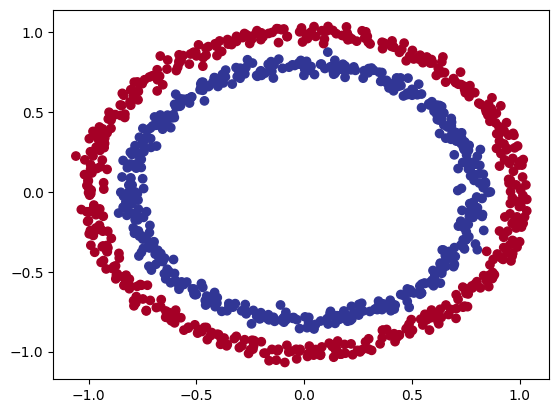

In [ ]:
# Visualize through a plot
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y, cmap= plt.cm.RdYlBu)


## Input and output shapes of nural network

In [ ]:
# Check the shapes of our features and lables

X.shape, y.shape


((1000, 2), (1000,))

In [ ]:
# How many samples we are working with
len(X) , len(y)

(1000, 1000)

In [ ]:
# View the First example of features and lables
X[0],y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

##Strps in modeling

The steps in modeling with Tensarflow are typically.

1. Create or import a model
2. Compile the model
3. Fit the model
4. Evaluate the model
5. Tweak
6. Evaluate... repeat tweak...Evaluate


In [ ]:
import tensorflow as tf

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model using the sequential API

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
    ])
# 2. Compile the model
model_1.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.SGD(),
    metrics= ["accuracy"]
)

# 3. Fit the model
model_1.fit(X,y , epochs = 5)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4780 - loss: 3.1626
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4990 - loss: 0.7650
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4970 - loss: 0.7149
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4940 - loss: 0.7017
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4920 - loss: 0.6972


In [ ]:
## lets improve the model by training for loger

model_1.fit(X,y, epochs=200, verbose=0)
model_1.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4730 - loss: 0.6933  


[0.6932879686355591, 0.4729999899864197]

Since we are working on a binary classification problem and our model is getting arround 50% accuracy
... its performing as it is guessing...

Lets step things upa knotch and add an extra layer

In [ ]:
from IPython.core.magics.execution import Module
# Set the random seed
tf.random.set_seed(42)

#1. Create a model with 2 layers
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

#2. Compile a model
model_2.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer= tf.keras.optimizers.SGD(),
    metrics = ["accuracy"])

#3. Fit a model
model_2.fit(X,y,epochs = 100, verbose = 0)

In [ ]:
#4 Evaluate the model

model_2.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4110 - loss: 0.6932


[0.6932164430618286, 0.41100001335144043]

In [ ]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (32.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

#improving our model
Lets look into our bag of tricks to see how we can improve our model

1. Create a model. - we might to add mode layers or increase the number of hidden units within a layer. - here we need to choose different optimization function such as Adam instead of SGD.
2. Compile a model.
3. fit a model - perhaps we can fit our model for more epochs(Leave it training for longer)

In [ ]:
# Set the random seed
tf.random.set_seed(42)

#1. Create a model_3
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])
#2. Compile the model
model_3.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["accuracy"]
)
#3.fit the model
model_3.fit(X,y,epochs = 100 , verbose=0)

In [ ]:
#4 Evaluate the model
model_3.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4860 - loss: 0.6946  


[0.6946008205413818, 0.4860000014305115]

To visualize our model predictions lets create function `plot_decession_boundry()`.config/
* Take a trained model, features(x) and lable (y)
* Create a mesh grid of different values
* Make predictions across the mesh grid
* Plot the predictions as well as aline between zones (where each unique class falls)

In [ ]:
import numpy as np
def plot_decession_boundry(model, X, y):
  """
  Plots the decession boundry created by a model predicting on X
  """

  #Define the accessboundry of the plot and create a mesh grid.
  x_min, x_max = X[:,0].min()-0.1, X[:,0].max()+0.1
  y_min, y_max = X[:,1].min()-0.1, X[:,0].max()+0.1

  xx,yy = np.meshgrid(np.linspace(x_min,x_max,100),
                      np.linspace(y_min,y_max, 100))
  # Create X value( we are going to make predictions on these)
  x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together

  # Make predictions
  y_pred = model.predict(x_in)

  # Check for multiclass
  if len(y_pred[0])>1:
    print("doing multiclass classification")
    # if so we have to rephrase our prediction to get them ready for plotting
    y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
  else:
    print("doing binary classification")
    y_pred = np.round(y_pred).reshape(xx.shape)

 # plot the decession boundary
  plt.contourf(xx,yy,y_pred, cmap= plt.cm.RdYlBu, alpha = 0.7)
  plt.scatter(X[:,0],X[:,1],c=y, s=40, cmap = plt.cm.RdYlBu)
  plt.xlim(xx.min(),xx.max())
  plt.ylim(yy.min(),yy.max())

In [ ]:
X,y

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        ...,
        [-0.13690036, -0.81001183],
        [ 0.67036156, -0.76750154],
        [ 0.28105665,  0.96382443]]),
 array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
        0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
        0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
        1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
        1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
        0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
        0, 1, 1, 0, 1, 0, 1, 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification


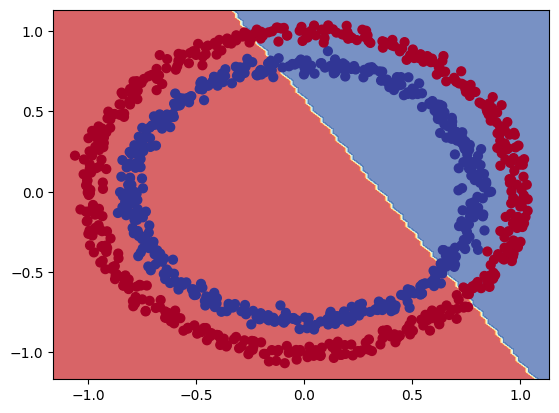

In [ ]:
# Check ot the predictions our model is making
plot_decession_boundry(model = model_3,
                       X=X,
                       y=y)

In [ ]:
# Lets see if our model can be used for regression problem
tf.random.set_seed(42)

# create some regression data

X_regression = tf.range(0,1000,5)
y_regression = tf.range(100,1100,5) # y= X+100

# Split our regression data into training and test sets
X_reg_train = X_regression[:150]
X_reg_test = X_regression[150:]
y_reg_train = y_regression[:150]
y_reg_test = y_regression[150:]

# Fit our model to regression data
model_3.fit(X_reg_train, y_reg_train, epochs=100)

Epoch 1/100


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("sequential_2_1/Cast:0", shape=(None,), dtype=float32) with name 'keras_tensor_5' and path ''. Expected shape (None, 2), but input has incompatible shape (None,)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None,), dtype=int32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
# Set up a random seed
tf.random.set_seed(42)
# 1. Create a model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss= tf.keras.losses.MeanAbsoluteError(),
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["mae"] )
# 3. Fit the model
model_3.fit(X_reg_train, y_reg_train, epochs = 100)

Epoch 1/100


ValueError: Input 0 with name 'None' of layer 'dense_6' is incompatible with the layer: expected min_ndim=2, found ndim=1. Full shape received: (None,)

In [ ]:
X_reg_train = tf.expand_dims(X_reg_train, axis=-1)
X_reg_test = tf.expand_dims(X_reg_test, axis=-1)

print(X_reg_train.shape)
print(X_reg_test.shape)

(150, 1)
(50, 1)


In [ ]:
from matplotlib import figure
# Make predictions with our trained model

y_reg_preds = model_3.predict(X_reg_test)

# Plot the predictions against the regressio data
plt.figure(figure=(10,7))

plt.scatter(X_reg_train, y_reg_train , c = 'b',label = 'Training data')
plt.scatter(X_reg_train, y_reg_train, c = 'g', label = 'Test data')

Lets try  build our forst neural network with a non linear activation function

In [ ]:
# Set seed
import tensorflow as tf

tf.random.set_seed(42)
# 1. Create a model with non linear activation
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation="relu")
])
# 2. Compile the model
model_5.compile(loss= tf.keras.losses.BinaryCrossentropy,
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ['accuracy'])
# 3. Fit the model
history = model_5.fit(X,y,epochs = 100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4840 - loss: 6.2958   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4850 - loss: 6.2591 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4860 - loss: 6.2300 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4860 - loss: 6.1922 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4860 - loss: 6.1873
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4870 - loss: 6.1854
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4870 - loss: 6.1661 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4840 - loss: 6.1379 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4840 - loss: 6.1282
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 6.1268
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4840 - loss: 6.1285 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - 

In [ ]:
#Set seed
tf.random.set_seed(42)
# 1 Create a model
model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation= 'relu'),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1,activation = "sigmoid")

])
# 2 Compile a model
model_7.compile(loss = "binary_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])
# 3 Fit the model
model_7.fit(X,y,epochs = 100)


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5020 - loss: 0.6925
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5010 - loss: 0.6903
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5070 - loss: 0.6886
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5130 - loss: 0.6871
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5140 - loss: 0.6858
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5220 - loss: 0.6847
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5240 - loss: 0.6837
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5270 - loss: 0.6827
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5280 - loss: 0.6817
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5340 - loss: 0.6808
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5320 - loss: 0.6799
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

In [ ]:
# Evaluate the model
model_7.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8250 - loss: 0.4768  


[0.4768258035182953, 0.824999988079071]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


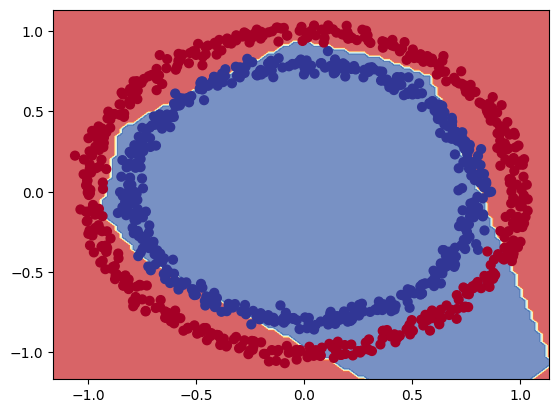

In [ ]:
# Check the prediction model is making

plot_decession_boundry(model= model_7, X=X, y=y)

# Finding the best learning rate

To find the ideal learning rate (the learning rate where the loss decreases the most during the training)

In [ ]:
# Set random seed
tf.random.set_seed(42)

# Create a model (same as model_8)
model_9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation= 'relu'),
    tf.keras.layers.Dense(4, activation="sigmoid")

])

# Compile the model
model_9.compile(
    loss= "binary_crossentropy",
    optimizer = "Adam",
    metrics = ['accuracy']
)
# Fit the model
# Create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epochs: 1e-4 * 10**(epochs/20))

history_9 = model_9.fit(X_reg_test,y_reg_train, epochs=100, callbacks = [lr_scheduler])

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 50
'y' sizes: 150
